This will be my final project for **Numerical Method**. In this code I will be working off of a project that I had done lasts semester with a man made chaos pendulum that I had built.

In [3]:
!pip install numpy matplotlib scipy

Defaulting to user installation because normal site-packages is not writeable
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached python_dateutil-2.9.0.post0-py2.py3-none-any.whl.metadata (8.4 kB)
  Using cached six-1.17.0-py2.py3-none-any.whl.metadata (1.7 kB)
   ---------------------------------------- 0.0/12.3 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/12.3 MB 7.2 MB/s eta 0:00:02
   -------- ------------------------------- 2.6/12.3 MB 6.7 MB/s eta 0:00:02
   ------------ --------------------------- 3.9/12.3 MB 7.0 MB/s eta 0:00:02
   ----------------- ---------------------- 5.5/12.3 MB 6.8 MB/s eta 0:00:02
   ---------------------- ----------------- 6.8/12.3 MB 6.9 MB/s eta 0:00:01
   --------------------------- ------------ 8.4/12.3 MB 7.0 MB/s eta 0:00:01
   ---------------------------------- ----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\Angelique\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [6]:
# import all the necessary packages

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint as int

In [7]:
# define the function that describes the pendulum's motion. This function will be used in the numerical integration process to compute the pendulum's trajectory over time. The function takes in the current state of the system (angle and angular velocity), time, natural frequency, and damping coefficient, and returns the derivatives of these quantities.

def pendulum(y, t, omega, b):
    theta, omega_dot = y
    dydt = [omega_dot, -b*omega_dot - omega**2 * np.sin(theta)]
    return dydt

<p align="center">
  By using the monte carlo equations I will be looking at more than one position. I will be looking <br> at a state (4 variables)
that will impact the position of my chaos pendulum at all times.
</p>

$$\mathbf{y} = \begin{bmatrix} \theta_1 \\ \omega_1 \\ \theta_2 \\ \omega_2 \end{bmatrix} = \begin{bmatrix} \text{Angle of top arm} \\ \text{Speed of top arm} \\ \text{Angle of bottom arm} \\ \text{Speed of bottom arm} \end{bmatrix}$$

In [13]:
# monte carlo simulation to explore the behavior of the pendulum under different initial conditions and parameters. This involves generating random initial angles and angular velocities, as well as varying the natural frequency and damping coefficient, to see how these factors influence the pendulum's motion. The results can be visualized using plots to show the trajectories of the pendulum over time for different scenarios.

# Set the parameters for the simulation
num_simulations = 100
time = np.linspace(0, 10, 1000)  # Time array from initial_time to final_time with num_points
results = []
for _ in range(num_simulations):
    # Randomly generate initial conditions and parameters
    initial_angle = np.random.uniform(-np.pi, np.pi)  # Initial angle between -pi and pi
    initial_angular_velocity = np.random.uniform(-5, 5)  # Initial angular velocity between -5 and 5
    natural_frequency = np.random.uniform(0.5, 2.0)  # Natural frequency between 0.5 and 2.0
    damping_coefficient = np.random.uniform(0.1, 0.5)  # Damping coefficient between 0.1 and 0.5
    
    # Initial state vector
    y0 = [initial_angle, initial_angular_velocity]
    
    # Integrate the pendulum equations over time
    sol = int(pendulum, y0, time, args=(natural_frequency, damping_coefficient))
    
    # Store the results for plotting
    results.append(sol)

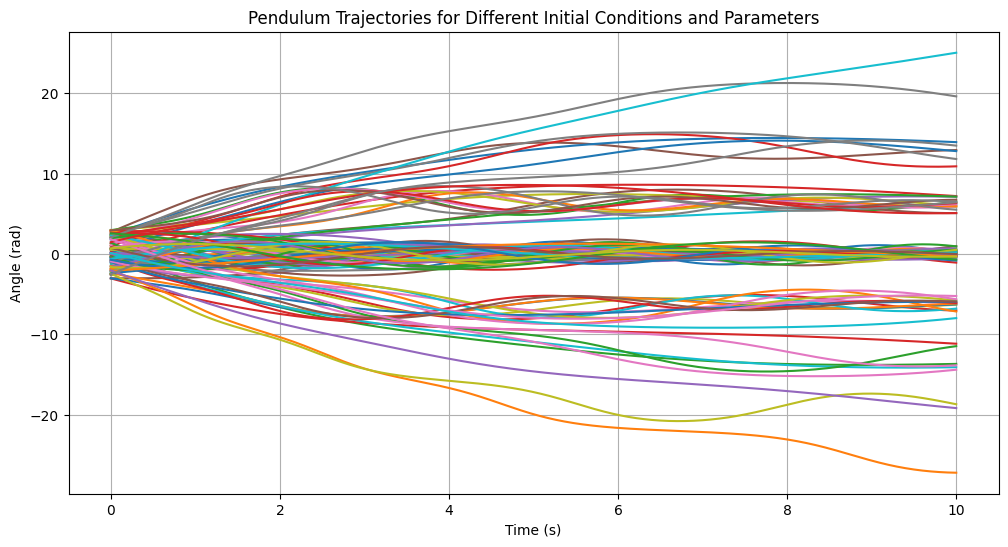

In [12]:
# Plot the results
plt.figure(figsize=(12, 6))
for sol in results:
    plt.plot(time, sol[:, 0])  # Plot angle over time
plt.title('Pendulum Trajectories for Different Initial Conditions and Parameters')
plt.xlabel('Time (s)')
plt.ylabel('Angle (rad)')
plt.grid()
plt.show()